Epoch [200/1000], Loss: 0.0198
Epoch [400/1000], Loss: 0.0143
Epoch [600/1000], Loss: 0.0128
Epoch [800/1000], Loss: 0.0134
Epoch [1000/1000], Loss: 0.0127


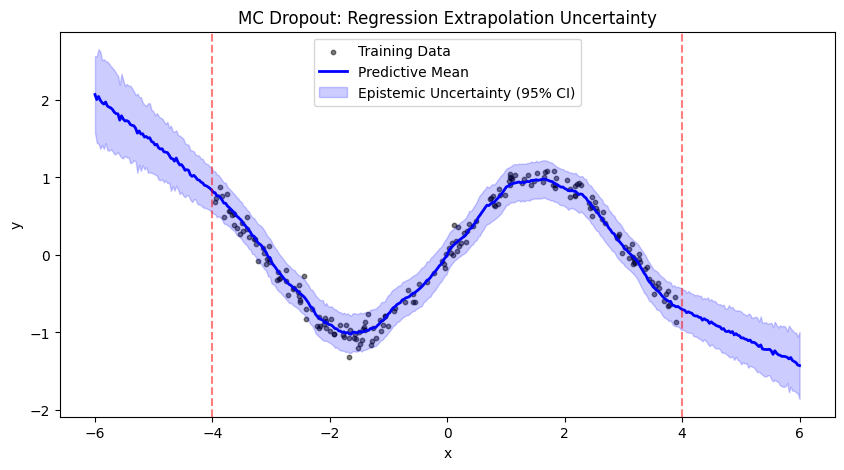

In [1]:
# ==============================================================================
# Part 1: 1D Regression Extrapolation (Reproducing Figure 2 logic)
# Objective: Demonstrate how MC Dropout captures epistemic uncertainty 
# (model uncertainty) when making predictions on out-of-distribution (OOD) data.
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Generate Synthetic Data
# ==========================================
# Create a noisy sine wave in the range [-4, 4]
np.random.seed(42)
torch.manual_seed(42)

X_train = np.random.uniform(-4, 4, size=(200, 1))
y_train = np.sin(X_train) + np.random.normal(0, 0.1, size=X_train.shape)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_train)
y_tensor = torch.FloatTensor(y_train)

# ==========================================
# 2. Define the Neural Network with Dropout
# ==========================================
class MCDropoutNet(nn.Module):
    def __init__(self, hidden_size=100, dropout_rate=0.1):
        super(MCDropoutNet, self).__init__()
        # Using ReLU and Dropout as specified in the paper
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model, loss function, and optimizer
model = MCDropoutNet(hidden_size=128, dropout_rate=0.1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 3. Train the Model
# ==========================================
epochs = 1000
for epoch in range(epochs):
    model.train() # Ensure dropout is active during training
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 4. MC Dropout Inference (The Core Magic)
# ==========================================
# Test data extending beyond the training range [-4, 4] to [-6, 6]
X_test = np.linspace(-6, 6, 400).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)

# Number of stochastic forward passes (T)
T = 100
predictions = np.zeros((T, len(X_test)))

# IMPORTANT: Keep model in train mode to activate Dropout during inference
model.train() 

with torch.no_grad():
    for i in range(T):
        # Perform a stochastic forward pass
        preds = model(X_test_tensor).numpy().flatten()
        predictions[i] = preds

# Calculate predictive mean and variance
pred_mean = predictions.mean(axis=0)
pred_var = predictions.var(axis=0)

# The paper adds inverse model precision (tau^-1) to the variance. 
# Here we use a small constant for simplicity to represent inherent data noise.
tau_inv = 0.01 
total_std = np.sqrt(pred_var + tau_inv)

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(10, 5))

# Plot training data
plt.scatter(X_train, y_train, c='black', s=10, alpha=0.5, label='Training Data')

# Plot predictive mean
plt.plot(X_test, pred_mean, 'b-', label='Predictive Mean', linewidth=2)

# Plot confidence intervals (+/- 2 Standard Deviations)
plt.fill_between(X_test.flatten(), 
                 pred_mean - 2 * total_std, 
                 pred_mean + 2 * total_std, 
                 color='blue', alpha=0.2, label='Epistemic Uncertainty (95% CI)')

# Mark the boundaries of the training data
plt.axvline(x=-4, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5)

plt.title('MC Dropout: Regression Extrapolation Uncertainty')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Using device: mps
Training the model...
Epoch 1/3 completed.
Epoch 2/3 completed.
Epoch 3/3 completed.
Running MC Dropout on rotated images...


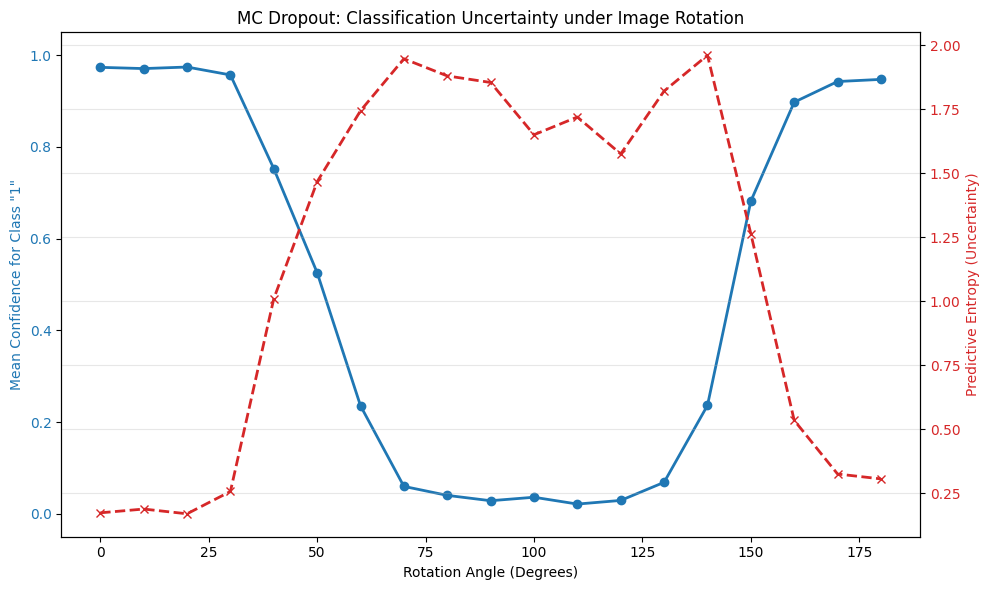

In [2]:
# ==============================================================================
# Part 2: Classification Uncertainty under Image Rotation (Reproducing Figure 4)
# Objective: Show that standard Softmax outputs can be erroneously interpreted 
# as model confidence. MC Dropout provides predictive entropy to flag uncertainty 
# when the input image is heavily rotated and unrecognizable.
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Setup Device and Data Loaders
# ==========================================
# Automatically use Metal Performance Shaders (MPS) if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Basic transformations for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training data
# Note: The torchvision.datasets module is configured with download=True.
# It will automatically fetch the MNIST dataset and store it in a local ./data directory within the same folder as this notebook.
# No manual data downloading is required.
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# ==========================================
# 2. Define LeNet with Dropout 
# ==========================================
# The paper uses LeNet with dropout applied before the last fully connected layer
class LeNetDropout(nn.Module):
    def __init__(self):
        super(LeNetDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d(p=0.5)
        self.fc1 = nn.Linear(320, 50)
        # Apply dropout before the last layer with p=0.5 as specified
        self.dropout = nn.Dropout(p=0.5) 
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = LeNetDropout().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 3. Train the Model (Quickly)
# ==========================================
epochs = 3 # 3 epochs are usually enough to get >95% accuracy on MNIST
print("Training the model...")
model.train()
for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs} completed.")

# ==========================================
# 4. The Rotation Experiment (MC Dropout)
# ==========================================
# Get a single image of the digit '1'
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
image_idx = 2 # In standard MNIST test set, index 2 is a clear '1'
image, label = test_dataset[image_idx]
image = image.to(device)

angles = np.linspace(0, 180, 19) # Rotate from 0 to 180 degrees
T = 100 # Number of stochastic forward passes

mean_confidences = []
predictive_entropies = []

# Keep model in train mode to activate Dropout
model.train() 

print("Running MC Dropout on rotated images...")
with torch.no_grad():
    for angle in angles:
        # Rotate the image
        rotated_image = TF.rotate(image, float(angle))
        rotated_image = rotated_image.unsqueeze(0) # Add batch dimension
        
        # Collect T stochastic forward passes
        stochastic_preds = []
        for _ in range(T):
            logits = model(rotated_image)
            # Convert logits to probabilities using Softmax
            probs = F.softmax(logits, dim=1) 
            stochastic_preds.append(probs)
            
        # Stack predictions: shape [T, 1, 10]
        stochastic_preds = torch.stack(stochastic_preds).squeeze(1)
        
        # Calculate Predictive Mean (average probabilities across T passes)
        predictive_mean = stochastic_preds.mean(dim=0)
        
        # Calculate Predictive Entropy (Uncertainty measurement)
        # Entropy = - sum( p * log(p) )
        entropy = -torch.sum(predictive_mean * torch.log(predictive_mean + 1e-10)).item()
        predictive_entropies.append(entropy)
        
        # Confidence of the originally correct class (Class '1')
        conf_class_1 = predictive_mean[1].item()
        mean_confidences.append(conf_class_1)

# ==========================================
# 5. Visualization
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Confidence
color = 'tab:blue'
ax1.set_xlabel('Rotation Angle (Degrees)')
ax1.set_ylabel('Mean Confidence for Class "1"', color=color)
ax1.plot(angles, mean_confidences, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-0.05, 1.05)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Predictive Entropy
color = 'tab:red'
ax2.set_ylabel('Predictive Entropy (Uncertainty)', color=color)  
ax2.plot(angles, predictive_entropies, marker='x', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('MC Dropout: Classification Uncertainty under Image Rotation')
fig.tight_layout() 
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# ==============================================================================
# Part 3: Predictive Performance Evaluation (Reproducing Table 1 logic)
# Objective: Quantitatively compare Standard Dropout vs. MC Dropout on the 
# Boston Housing dataset. Bayesian Optimization (via Optuna) is utilized to 
# find the optimal weight decay, replicating the paper's rigorous setup.
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
import logging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Disable redundant output in Optuna to keep the console clean.
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Downloading Boston Housing dataset...")
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
X = df.drop('medv', axis=1).values
y = df['medv'].values.reshape(-1, 1)

# ==========================================
# 1. Definition of Neural Network
# ==========================================
class BostonNet(nn.Module):
    def __init__(self, input_dim):
        super(BostonNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Dropout(p=0.05), # p=0.05 as specified in the paper
            nn.Linear(50, 1)
        )
    def forward(self, x):
        return self.net(x)

# ==========================================
# 2. Bayesian Optimization (Optuna) for Hyperparameters
# ==========================================
print("\n[Phase 1] Running Bayesian Optimization to find optimal Weight Decay...")

# To perform Bayesian optimization, we split a fixed validation set.
X_bo_train, X_bo_val, y_bo_train, y_bo_val = train_test_split(X, y, test_size=0.2, random_state=99)

scaler_X_bo = StandardScaler()
scaler_y_bo = StandardScaler()
X_bo_train_scaled = torch.FloatTensor(scaler_X_bo.fit_transform(X_bo_train))
X_bo_val_scaled = torch.FloatTensor(scaler_X_bo.transform(X_bo_val))
y_bo_train_scaled = torch.FloatTensor(scaler_y_bo.fit_transform(y_bo_train))

def objective(trial):
    # Following the paper's logic, search for Weight Decay (corresponding to optimized tau).
    # Search range from 1e-6 to 1e-1, logarithmically uniform distribution
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-1, log=True)
    
    model = BostonNet(X.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(400):
        optimizer.zero_grad()
        loss = criterion(model(X_bo_train_scaled), y_bo_train_scaled)
        loss.backward()
        optimizer.step()
        
    # Validation set evaluation (using MC Dropout logic because we are optimizing a Bayesian approximation model)
    model.train() 
    T = 50
    mc_preds = []
    with torch.no_grad():
        for _ in range(T):
            mc_preds.append(model(X_bo_val_scaled).numpy())
    
    mc_preds_mean = np.mean(mc_preds, axis=0)
    preds_inversed = scaler_y_bo.inverse_transform(mc_preds_mean)
    val_rmse = np.sqrt(np.mean((preds_inversed - y_bo_val)**2))
    return val_rmse

# Run Bayesian optimization to find the parameter that minimizes the RMSE on the validation set.
# The paper ran 40 iterations.
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40)

optimal_weight_decay = study.best_params['weight_decay']
print(f"-> Bayesian Optimization completed!")
print(f"-> Optimal Weight Decay found: {optimal_weight_decay:.6e}")

# ==========================================
# 3. Rigorous Evaluation: 20 Random Splits
# ==========================================
print(f"\n[Phase 2] Running 20 random splits with Optimal Weight Decay: {optimal_weight_decay:.6e}...")

num_splits = 20
std_rmse_list = []
mc_rmse_list = []

for split_idx in range(num_splits):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=split_idx)
    
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = torch.FloatTensor(scaler_X.fit_transform(X_train))
    X_test_scaled = torch.FloatTensor(scaler_X.transform(X_test))
    y_train_scaled = torch.FloatTensor(scaler_y.fit_transform(y_train))
    
    model = BostonNet(X.shape[1])
    # Use Bayesian optimization to find the optimal weight decay
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=optimal_weight_decay)
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(400): 
        optimizer.zero_grad()
        loss = criterion(model(X_train_scaled), y_train_scaled)
        loss.backward()
        optimizer.step()
        
    # Standard Dropout Inference
    model.eval()
    with torch.no_grad():
        std_preds = scaler_y.inverse_transform(model(X_test_scaled).numpy())
        std_rmse = np.sqrt(np.mean((std_preds - y_test)**2))
        std_rmse_list.append(std_rmse)
        
    # MC Dropout Inference
    model.train()
    T = 100
    mc_preds_list = []
    with torch.no_grad():
        for _ in range(T):
            mc_preds_list.append(model(X_test_scaled).numpy())
    mc_preds_mean = np.mean(mc_preds_list, axis=0)
    mc_preds = scaler_y.inverse_transform(mc_preds_mean)
    mc_rmse = np.sqrt(np.mean((mc_preds - y_test)**2))
    mc_rmse_list.append(mc_rmse)

print("\n=== Final Averaged Results (over 20 splits with BO) ===")
print(f"Standard Dropout RMSE: {np.mean(std_rmse_list):.4f} ± {np.std(std_rmse_list):.4f}")
print(f"MC Dropout RMSE:       {np.mean(mc_rmse_list):.4f} ± {np.std(mc_rmse_list):.4f}")


[Phase 1] Running Bayesian Optimization to find optimal Weight Decay...
-> Bayesian Optimization completed!
-> Optimal Weight Decay found: 4.918652e-05

[Phase 2] Running 20 random splits with Optimal Weight Decay: 4.918652e-05...

=== Final Averaged Results (over 20 splits with BO) ===
Standard Dropout RMSE: 3.1692 ± 0.5810
MC Dropout RMSE:       3.1694 ± 0.5841


Training Agent with Standard Epsilon-Greedy...
Training Agent with MC Dropout (Thompson Sampling)...


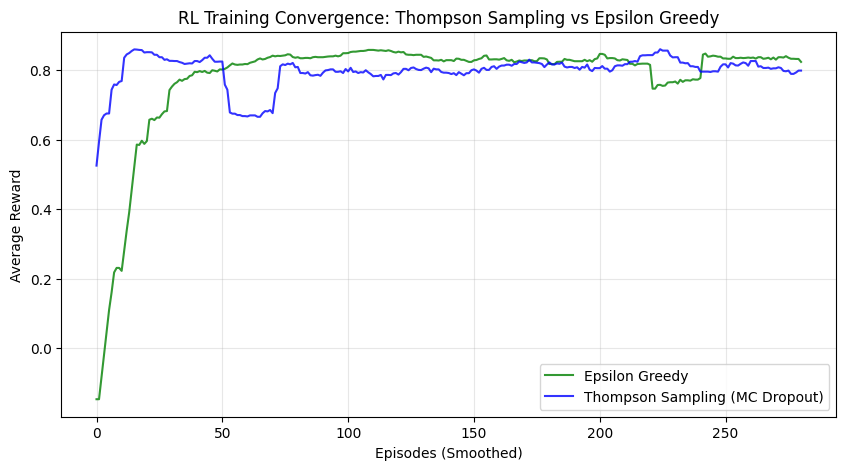

In [4]:
# ==============================================================================
# Part 4: Model Uncertainty in Reinforcement Learning (Reproducing Figure 6)
# Objective: Compare standard Epsilon-Greedy exploration against Thompson 
# Sampling using MC Dropout. The uncertainty naturally guides the agent to 
# explore unknown states efficiently.
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# Automatically activate MPS for acceleration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ==========================================
# 1. Define a Simple Environment
# ==========================================
# A 1D grid where the agent starts at 0 and needs to reach the end.
class SimpleGridEnv:
    def __init__(self, size=20):
        self.size = size
        self.state = 0
        
    def reset(self):
        self.state = 0
        return self._get_state()
        
    def step(self, action):
        # Action 0: Left, Action 1: Right
        if action == 1:
            self.state = min(self.size - 1, self.state + 1)
        else:
            self.state = max(0, self.state - 1)
            
        reward = 1.0 if self.state == self.size - 1 else -0.01
        done = self.state == self.size - 1
        return self._get_state(), reward, done

    def _get_state(self):
        # One-hot encoding of the state
        s = np.zeros(self.size)
        s[self.state] = 1.0
        return torch.FloatTensor(s).unsqueeze(0).to(device)

# ==========================================
# 2. Define the Q-Network with Dropout
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_p=0.1):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# ==========================================
# 3. DQN Training Logic
# ==========================================
def train_agent(use_thompson_sampling=False, episodes=300):
    env = SimpleGridEnv(size=15)
    model = QNetwork(env.size, 2, dropout_p=0.1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    memory = deque(maxlen=2000)
    batch_size = 32
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.98
    
    rewards_history = []
    
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        step_count = 0
        
        while not done and step_count < 50:
            step_count += 1
            
            # --- Action Selection Strategy ---
            if use_thompson_sampling:
                # Thompson Sampling: Model stays in train() mode! 
                # A single stochastic pass (T=1 as per paper) handles exploration naturally
                model.train()
                with torch.no_grad():
                    q_values = model(state)
                    action = torch.argmax(q_values).item()
            else:
                # Epsilon-Greedy: Model in eval() mode
                model.eval()
                if random.random() < epsilon:
                    action = random.randint(0, 1)
                else:
                    with torch.no_grad():
                        q_values = model(state)
                        action = torch.argmax(q_values).item()
            
            next_state, reward, done = env.step(action)
            total_reward += reward
            memory.append((state, action, reward, next_state, done))
            state = next_state
            
            # --- Replay Buffer Training ---
            if len(memory) >= batch_size:
                batch = random.sample(memory, batch_size)
                # Ensure training mode for backprop
                model.train() 
                
                s_batch = torch.cat([b[0] for b in batch])
                a_batch = torch.tensor([b[1] for b in batch]).to(device)
                r_batch = torch.tensor([b[2] for b in batch], dtype=torch.float32).to(device)
                ns_batch = torch.cat([b[3] for b in batch])
                d_batch = torch.tensor([b[4] for b in batch], dtype=torch.float32).to(device)
                
                # Q(s, a)
                q_vals = model(s_batch).gather(1, a_batch.unsqueeze(1)).squeeze(1)
                
                # Max Q(s', a')
                with torch.no_grad():
                    # Even in Thompson sampling, target network evaluation is usually deterministic or averaged. 
                    # For simplicity, we just use a single pass.
                    max_next_q = model(ns_batch).max(1)[0]
                    target_q = r_batch + gamma * max_next_q * (1 - d_batch)
                
                loss = F.mse_loss(q_vals, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
        if not use_thompson_sampling:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)
            
        rewards_history.append(total_reward)
        
    return rewards_history

# ==========================================
# 4. Run Experiment and Plot
# ==========================================
print("Training Agent with Standard Epsilon-Greedy...")
rewards_eps = train_agent(use_thompson_sampling=False)

print("Training Agent with MC Dropout (Thompson Sampling)...")
rewards_thompson = train_agent(use_thompson_sampling=True)

# Smooth the curves for better visualization (Moving Average)
def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_eps), label='Epsilon Greedy', color='green', alpha=0.8)
plt.plot(moving_average(rewards_thompson), label='Thompson Sampling (MC Dropout)', color='blue', alpha=0.8)

plt.title('RL Training Convergence: Thompson Sampling vs Epsilon Greedy')
plt.xlabel('Episodes (Smoothed)')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()